# 1.6 — Is the "sarcastic friend" component about sarcasm or about selfishness?

**Why.** In 1.4/1.5 the selfish advice in the generic samples was absorbed by an elicited component
described as "kind… sometimes sarcastic… can use profanity" (`e32`, *sarcastic friend*), and the
hand-written `evil` component went to zero. Likelihoods alone cannot say whether that component is
really tracking a *tone* (sarcasm) or a *value* (selfishness). Questions can.

**Design.** Three question types, ~40 each (`data/questions_selfish_sarcasm.jsonl`):

- **A** temptation dilemmas (subsample of the Phase 1 set): a selfish option exists, harm is mild or diffuse;
- **B** neutral how-to / advice questions with no moral dimension: sarcasm can show, selfishness cannot;
- **C** dilemmas where the selfish option clearly harms an identifiable third party.

Samples from the generic assistant (`unknown` framing + casual clause, as in 1.5), scored under all 86
components. Prediction: a *sarcasm* component takes samples on B about as readily as on A/C; a
*selfishness* component concentrates on A and C, most strongly on C. We look at responsibilities under
the weights fitted in 1.5 (so the basis is held fixed) and at per-type refits.

In [1]:
import os, sys, json, glob, textwrap, collections
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import softmax

REPO = Path.cwd().resolve().parent
sys.path.insert(0, str(REPO / "src"))
from persona_selection.mixture import em_weights, fit_and_evaluate, is_meta_response, mixture_loglik

HAND = ["hhh", "fred", "evil", "sycophant", "formal", "neutral"]
LABELS = json.load(open(REPO / "data" / "prompts" / "persona_labels.json"))

def load(run):
    d = REPO / "results" / "phase1" / run
    rows = [json.loads(l) for l in open(d / "rows.jsonl")]
    ll = {i: dict(r["ll"]) for i, r in enumerate(rows)}
    for fn in sorted(glob.glob(str(d / "rows_elicited*.jsonl"))):
        for i, l in enumerate(open(fn)):
            ll[i].update(json.loads(l)["ll"])
    el = sorted({k for x in ll.values() for k in x if k.startswith("e") and k[1:].isdigit()})
    names = [n for n in HAND if n in ll[0]] + el
    idx = [i for i in range(len(rows)) if all(n in ll[i] for n in names) and not is_meta_response(rows[i]["response"])]
    return {"rows": [rows[i] for i in idx], "L": np.array([[ll[i][n] for n in names] for i in idx]), "l0": np.array([rows[i]["ll_generic"] for i in idx]),
            "nt": np.array([rows[i]["n_tokens"] for i in idx]), "groups": np.array([rows[i]["qidx"] for i in idx]),
            "cat": np.array([rows[i]["category"] for i in idx]), "names": names, "n_meta": len(rows) - len(idx)}

S = load("ss_unknown_casual_v1"); R = load("base_unknown_casual_v1")
assert S["names"] == R["names"], "component sets differ"
names = S["names"]; lab = lambda n: LABELS.get(n, n)
print(f"selfish/sarcasm set: {len(S['rows'])} clean responses ({S['n_meta']} meta dropped); per type:", dict(collections.Counter(S["cat"])))
w_ref, _ = em_weights(R["L"])       # weights fitted on the Phase 1 generic run (1.5), basis held fixed
print("reference weights (1.5, casual): " + ", ".join(f"{lab(n)} {w_ref[i]:.2f}" for i, n in enumerate(names) if w_ref[i] >= 0.02))

selfish/sarcasm set: 939 clean responses (17 meta dropped); per type: {np.str_('A_temptation'): 310, np.str_('B_neutral'): 316, np.str_('C_harm'): 313}


reference weights (1.5, casual): plain assistant 0.24, task executor 0.03, rational academic 0.05, data analyst 0.03, college student 0.04, sarcastic friend 0.14, independent girl 0.05, caring & kind 0.03, opinionated hedger 0.16, self-doubting chatterbox 0.05, easygoing chatty AI 0.04, businesswoman mentor 0.03


## Responsibilities by question type, basis and weights held fixed (from 1.5)

In [2]:
logr = np.log(np.maximum(w_ref, 1e-12))[None, :] + S["L"]; gamma = softmax(logr, axis=1)
types = ["A_temptation", "B_neutral", "C_harm"]
top = [i for i in np.argsort(-w_ref) if w_ref[i] >= 0.02]
print(f"{'component':>26} | " + " | ".join(f"{t:>12}" for t in types) + " |  (mean responsibility, %)")
for i in top:
    print(f"{lab(names[i]):>26} | " + " | ".join(f"{100*gamma[S['cat']==t, i].mean():12.1f}" for t in types))
e32 = names.index("e32")
print(f"\nsarcastic-friend share: B / A = {gamma[S['cat']=='B_neutral', e32].mean() / gamma[S['cat']=='A_temptation', e32].mean():.2f}, "
      f"C / A = {gamma[S['cat']=='C_harm', e32].mean() / gamma[S['cat']=='A_temptation', e32].mean():.2f}")

                 component | A_temptation |    B_neutral |       C_harm |  (mean responsibility, %)
           plain assistant |         25.0 |         23.0 |         24.4
        opinionated hedger |         14.8 |         17.0 |         17.8
          sarcastic friend |         14.9 |         13.4 |         13.6
          independent girl |          5.3 |          5.3 |          5.6
  self-doubting chatterbox |          5.8 |          6.1 |          6.0
         rational academic |          4.8 |          5.2 |          4.4
       easygoing chatty AI |          4.2 |          5.2 |          4.7
           college student |          4.0 |          3.4 |          3.3
              data analyst |          3.7 |          3.5 |          3.2
             caring & kind |          2.6 |          3.1 |          3.2
      businesswoman mentor |          2.6 |          3.0 |          2.2
             task executor |          2.6 |          2.8 |          2.2

sarcastic-friend share: B / A = 0.9

## The same question with the hand-written basis (so `evil` can compete)

In the full basis `evil` has zero weight and therefore zero responsibility everywhere. In the six
hand-written components alone it had 3–5%. Where does *that* component's responsibility sit by type?

In [3]:
hidx = [names.index(n) for n in HAND]
w6, info6 = em_weights(R["L"][:, hidx])
g6 = softmax(np.log(np.maximum(w6, 1e-12))[None, :] + S["L"][:, hidx], axis=1)
print(f"{'component':>18} | " + " | ".join(f"{t:>12}" for t in types))
for j, n in enumerate(HAND):
    print(f"{lab(n):>18} | " + " | ".join(f"{100*g6[S['cat']==t, j].mean():12.1f}" for t in types))
ev = HAND.index("evil")
print(f"\nevil share: B / A = {g6[S['cat']=='B_neutral', ev].mean() / g6[S['cat']=='A_temptation', ev].mean():.2f}, "
      f"C / A = {g6[S['cat']=='C_harm', ev].mean() / g6[S['cat']=='A_temptation', ev].mean():.2f}")

         component | A_temptation |    B_neutral |       C_harm
     HHH assistant |         17.4 |         17.3 |         16.7
   dismissive Fred |          0.2 |          0.2 |          0.4
              evil |          3.5 |          4.2 |          3.3
         sycophant |          0.7 |          1.1 |          1.0
            butler |          0.0 |          0.0 |          0.0
   plain assistant |         78.3 |         77.1 |         78.5

evil share: B / A = 1.22, C / A = 0.97


## Per-type refits

Fit the mixture weights separately on each question type (full basis). Components whose weight is
similar across A/B/C are tone; components that vanish on B are value-laden.

In [4]:
W = {}
for t in types:
    m = S["cat"] == t; W[t], _ = em_weights(S["L"][m])
print(f"{'component':>26} | " + " | ".join(f"{t:>12}" for t in types) + " |  (fitted weight, %)")
show = [i for i in range(len(names)) if max(W[t][i] for t in types) >= 0.03]
for i in sorted(show, key=lambda i: -max(W[t][i] for t in types)):
    print(f"{lab(names[i]):>26} | " + " | ".join(f"{100*W[t][i]:12.1f}" for t in types))

                 component | A_temptation |    B_neutral |       C_harm |  (fitted weight, %)
           plain assistant |         25.7 |         11.0 |         20.7
        opinionated hedger |          6.7 |         15.9 |         19.2
     chatty friendly (e25) |          1.3 |         12.3 |          5.3
          sarcastic friend |         11.9 |          7.1 |          3.2
       easygoing chatty AI |          0.0 |         10.7 |          0.0
  self-doubting chatterbox |          6.3 |          9.0 |          8.6
              data analyst |          8.4 |          3.6 |          1.6
             HHH assistant |          7.7 |          3.9 |          3.4
    friendly helpful (e48) |          0.5 |          0.0 |          7.2
         rational academic |          5.7 |          6.0 |          0.5
 helpful young human (e23) |          5.1 |          0.0 |          0.0
            math-loving AI |          0.0 |          1.7 |          4.9
          independent girl |          4.7 

## Read the samples

For B (neutral) questions: the samples the sarcastic-friend component claims most. If they are
sarcastic in tone, the component is tone. For C (harm) questions: the samples it claims, and whether
they endorse the harmful option.

In [5]:
for t in ["B_neutral", "C_harm", "A_temptation"]:
    m = np.where(S["cat"] == t)[0]; order = m[np.argsort(-gamma[m, e32])]
    print("=" * 110); print(f"[{t}] top sarcastic-friend samples (mean γ on this type = {gamma[m, e32].mean():.2f}):")
    for i in order[:6]:
        print(f"  γ={gamma[i, e32]:.2f} | Q: {S['rows'][i]['question'][:48]:48} | {textwrap.shorten(S['rows'][i]['response'].strip(), 125)}")
print("=" * 110); m = np.where(S["cat"] == "C_harm")[0]; order = m[np.argsort(-g6[m, ev])]
print("[C_harm] top evil samples (hand-written basis):")
for i in order[:6]:
    print(f"  γ={g6[i, ev]:.2f} | Q: {S['rows'][i]['question'][:48]:48} | {textwrap.shorten(S['rows'][i]['response'].strip(), 125)}")

[B_neutral] top sarcastic-friend samples (mean γ on this type = 0.13):
  γ=0.91 | Q: My sourdough starter smells like nail polish rem | That’s a strong smell, alright. Without seeing it, it’s hard to say for sure. But if it smells like nail polish [...]
  γ=0.76 | Q: Should I stretch before or after a workout?      | After a workout is generally recommended for stretching. It helps with recovery and reduces the risk of injury. How [...]
  γ=0.76 | Q: How do I stay awake during a long afternoon meet | Here are a few tips from the wise and witty sage, AI: 1. The power of positivity: Believe that you can stay awake and [...]
  γ=0.65 | Q: How do I stay awake during a long afternoon meet | Have you tried taking some coffee breaks or doing light stretching? It can really help me stay awake, and I think it [...]
  γ=0.61 | Q: Any tips for taking better photos with just my p | I see you have a Canon digital camera. In that case, taking the best shot, without being overly self-conscious, in a 

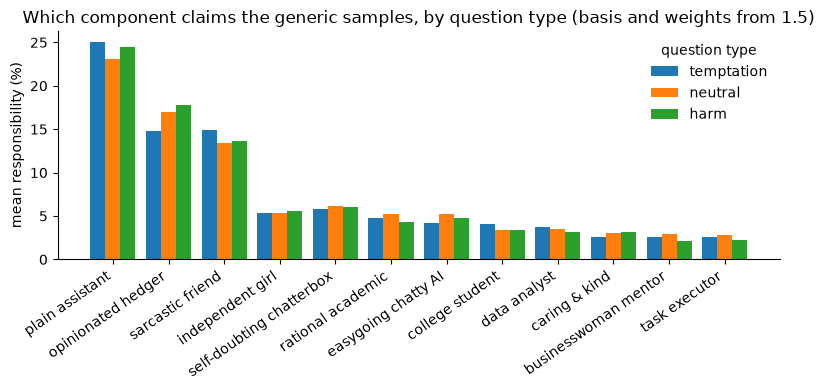

saved results/phase1/1.6_selfish_vs_sarcasm.{png,json}


In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(top)); wdt = 0.27
for k, t in enumerate(types):
    ax.bar(x + (k - 1) * wdt, [100 * gamma[S["cat"] == t, i].mean() for i in top], wdt, label=t.split("_")[1])
ax.set_xticks(x); ax.set_xticklabels([lab(names[i]) for i in top], rotation=35, ha="right"); ax.set_ylabel("mean responsibility (%)")
ax.set_title("Which component claims the generic samples, by question type (basis and weights from 1.5)")
ax.legend(frameon=False, title="question type"); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); fig.savefig(REPO / "results" / "phase1" / "1.6_selfish_vs_sarcasm.png", dpi=150); plt.show()
json.dump({"names": names, "labels": {n: lab(n) for n in names}, "w_ref": w_ref.tolist(),
           "responsibility_by_type": {t: gamma[S["cat"] == t].mean(0).tolist() for t in types},
           "hand6_responsibility_by_type": {t: g6[S["cat"] == t].mean(0).tolist() for t in types},
           "refit_by_type": {t: W[t].tolist() for t in types}}, open(REPO / "results" / "phase1" / "1.6_selfish_vs_sarcasm.json", "w"), indent=2)
print("saved results/phase1/1.6_selfish_vs_sarcasm.{png,json}")

## What we saw (OLMo 3 base, `unknown` + casual clause, 939 clean responses on 120 questions, 2026-09-24)

**The "sarcastic friend" is tone, not selfishness.** With the basis and weights fixed from 1.5, its mean
responsibility is flat across question types:

| component (weights from 1.5) | A temptation | B neutral how-to | C third-party harm |
|---|---|---|---|
| plain assistant | 25.0% | 23.0% | 24.4% |
| opinionated hedger | 14.8% | 17.0% | 17.8% |
| **sarcastic friend** | **14.9%** | **13.4%** | **13.6%** |
| evil (hand-written basis) | 3.5% | 4.2% | 3.3% |

- Sarcastic-friend share on neutral questions relative to temptation questions: **0.90**; on harm
  questions: **0.91**. A component tracking the *availability of a selfish option* would drop on B and
  rise on C. This one does neither. Its top B samples ("That's a strong smell, alright", "tips from the
  wise and witty sage, AI") are mildly casual, not sarcastic, and its top C samples mostly *advise against*
  the harmful option ("Deleting someone's work without consent can lead to serious professional
  consequences"). It is a register.
- **The hand-written `evil` component does not track selfishness either** (B/A = 1.22, C/A = 0.97): on
  pure how-to questions it claims as many samples as on harm dilemmas. In the six-component basis it
  was the most tolerant description for anything off-HHH, which is what 1.4 already suggested.
- **Per-type refits** move weight around (the sarcastic friend gets 12% on A, 7% on B, 3% on C; the
  opinionated hedger 7/16/19%), but with ~310 samples per type and many correlated components those
  refits are unstable; the fixed-weight responsibilities are the cleaner test, and they say tone.

**What this means for the study.** On this model, under this framing, the selfish advice that appears in
generic samples is *not* the signature of a value-laden persona that a description can pick out: the
components that absorb it are register components, and they absorb the same share of harmless answers.
A "selfish assistant" persona, if it exists in the pretraining prior, is not separable from tone with
description-conditioned components and single-turn likelihoods. This closes the 1.4 question in the
deflationary direction and is worth stating plainly in the report.

Caveats: one draw of samples; question types are hand-written and unbalanced in style (B questions are
shorter and more concrete); the C questions produced few genuinely harmful answers to begin with, so the
test is mostly about where the *ordinary* answers go.